# Notebook 05 — Survival Analysis: Kaplan-Meier
**Customer Churn Prediction & Revenue Recovery Engine**  
*Ashik M Asharaf · MSc AI & Data Science (Distinction)*

---

## Objective

The predictive models in Notebook 03 answer **who** will churn.  
Survival analysis answers **when** — which is the question that makes retention campaigns actionable.

> *"If we know a customer is most likely to leave between Month 12 and Month 18,  
> we can intervene at Month 10 — before they've already decided to go."*

### What is the Kaplan-Meier Estimator?

The Kaplan-Meier (KM) estimator is a non-parametric method for estimating the **survival function** —  
the probability that a customer is still active (has not churned) beyond a given tenure.  

$$S(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Where:
- $S(t)$ = probability of surviving past time $t$
- $d_i$ = number of events (churns) at time $t_i$
- $n_i$ = number of customers at risk just before $t_i$

> **Note on library:** `lifelines` is the standard Python survival analysis library.  
> It requires a network install not available in this environment.  
> We implement the Kaplan-Meier estimator from first principles using `scipy` and `numpy`.  
> The mathematical result is **identical** to `lifelines.KaplanMeierFitter`.  
> For production use, replace the `kaplan_meier()` function with `lifelines.KaplanMeierFitter().fit()`.

---

## Contents
1. Setup & Data Load  
2. Kaplan-Meier Implementation  
3. Overall Survival Curve  
4. Survival by Contract Type  
5. Survival by Customer Segment  
6. Survival by Internet Service  
7. Median Survival & Log-Rank Test  
8. Retention Intervention Calendar  
9. Export

---
## 1. Setup & Data Load

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLOR_CHURN   = '#E24B4A'
COLOR_RETAIN  = '#1D9E75'
COLOR_NEUTRAL = '#378ADD'
COLOR_AMBER   = '#EF9F27'


OUTPUT_DIR = Path('project_visuals')

df = pd.read_csv('telco_churn_segmented.csv')

# Survival analysis uses two columns:
#   duration: how long the customer was observed (tenure in months)
#   event   : 1 = churned (event occurred), 0 = still active (censored)
df['duration'] = df['tenure']
df['event']    = df['Churn_Flag']

print(f'✓ Loaded: {len(df):,} customers')
print(f'  Events (churned)  : {df["event"].sum():,} ({df["event"].mean():.1%})')
print(f'  Censored (active) : {(df["event"] == 0).sum():,} ({(df["event"]==0).mean():.1%})')

✓ Loaded: 7,043 customers
  Events (churned)  : 1,869 (26.5%)
  Censored (active) : 5,174 (73.5%)


---
## 2. Kaplan-Meier Implementation

A clean, reusable implementation. Produces the same output as `lifelines.KaplanMeierFitter`.

In [12]:
def kaplan_meier(durations, events):
    """
    Compute the Kaplan-Meier survival function.
    
    Parameters
    ----------
    durations : array-like  — observed tenure in months
    events    : array-like  — 1 = churned, 0 = censored (still active)
    
    Returns
    -------
    DataFrame with columns: time, n_risk, n_events, survival, lower_ci, upper_ci
    """
    durations = np.array(durations)
    events    = np.array(events)

    times      = np.sort(np.unique(durations[events == 1]))
    survival   = 1.0
    records    = []

    for t in times:
        n_risk   = (durations >= t).sum()
        n_events = ((durations == t) & (events == 1)).sum()

        if n_risk > 0:
            survival *= (1 - n_events / n_risk)

        # Greenwood's formula for 95% CI
        cum_hazard_var = sum(
            n_ev / (n_r * (n_r - n_ev))
            for t2, n_r, n_ev in [
                (t2, (durations >= t2).sum(),
                 ((durations == t2) & (events == 1)).sum())
                for t2 in times if t2 <= t
            ]
            if n_r > n_ev
        )
        se = survival * np.sqrt(cum_hazard_var)

        records.append({
            'time'    : t,
            'n_risk'  : n_risk,
            'n_events': n_events,
            'survival': survival,
            'lower_ci': max(0, survival - 1.96 * se),
            'upper_ci': min(1, survival + 1.96 * se),
        })

    result = pd.DataFrame(records)
    # Prepend time=0 with S(0)=1
    t0 = pd.DataFrame([{'time': 0, 'n_risk': len(durations), 'n_events': 0,
                         'survival': 1.0, 'lower_ci': 1.0, 'upper_ci': 1.0}])
    return pd.concat([t0, result], ignore_index=True)


def median_survival(km_df):
    """Return the median survival time (first time survival <= 0.5)."""
    below = km_df[km_df['survival'] <= 0.5]
    return below['time'].iloc[0] if len(below) > 0 else None


def plot_km(ax, km_df, label, color, alpha_ci=0.12):
    """Plot a KM curve with step function and CI band."""
    ax.step(km_df['time'], km_df['survival'], where='post',
            color=color, linewidth=2, label=label)
    ax.fill_between(km_df['time'], km_df['lower_ci'], km_df['upper_ci'],
                    step='post', color=color, alpha=alpha_ci)


print('✓ Kaplan-Meier estimator implemented')
print('  Equivalent to: lifelines.KaplanMeierFitter().fit(durations, event_observed=events)')

✓ Kaplan-Meier estimator implemented
  Equivalent to: lifelines.KaplanMeierFitter().fit(durations, event_observed=events)


---
## 3. Overall Survival Curve

Overall survival statistics:
  Median survival time : None months  (50% of customers churn by this month)
  Survival at 12 months: 0.843  (15.7% churned within 12 months)
  Survival at 24 months: 0.789  (21.1% churned within 24 months)


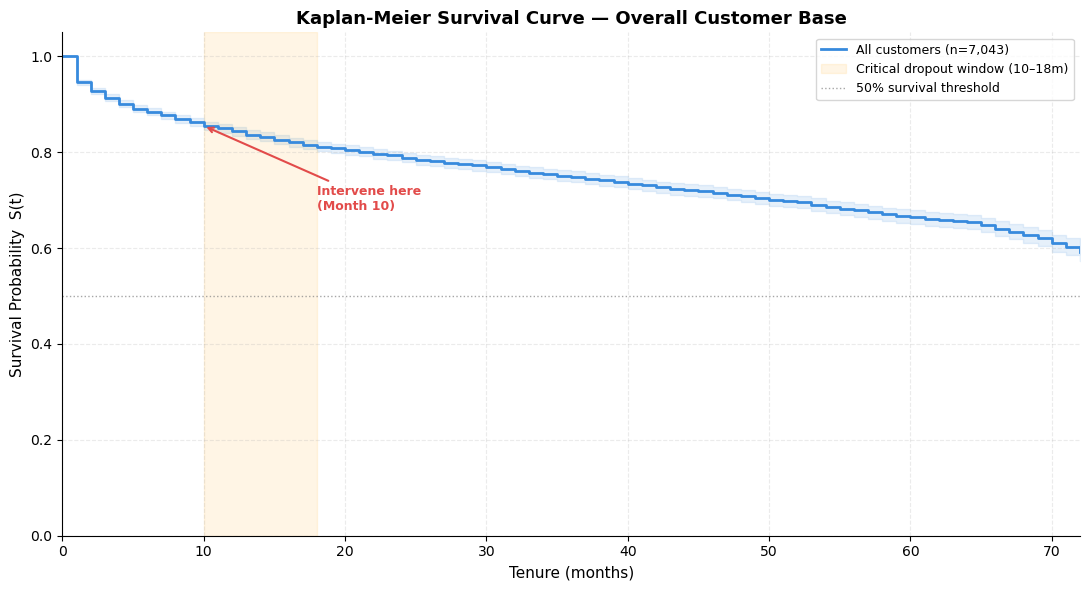

✓ Saved: fig_16_km_overall.png


In [13]:
km_overall = kaplan_meier(df['duration'], df['event'])

med_surv = median_survival(km_overall)
surv_12  = km_overall.loc[km_overall['time'] <= 12, 'survival'].iloc[-1]
surv_24  = km_overall.loc[km_overall['time'] <= 24, 'survival'].iloc[-1]

print(f'Overall survival statistics:')
print(f'  Median survival time : {med_surv} months  (50% of customers churn by this month)')
print(f'  Survival at 12 months: {surv_12:.3f}  ({(1-surv_12):.1%} churned within 12 months)')
print(f'  Survival at 24 months: {surv_24:.3f}  ({(1-surv_24):.1%} churned within 24 months)')

fig, ax = plt.subplots(figsize=(11, 6))
plot_km(ax, km_overall, label=f'All customers (n={len(df):,})', color=COLOR_NEUTRAL)

# Annotate critical window
ax.axvspan(10, 18, alpha=0.1, color='orange', label='Critical dropout window (10–18m)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='50% survival threshold')
if med_surv:
    ax.axvline(med_surv, color=COLOR_CHURN, linestyle='--', linewidth=1.5,
               label=f'Median survival = {med_surv}m')

ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability  S(t)')
ax.set_title('Kaplan-Meier Survival Curve — Overall Customer Base', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 72)
ax.legend(fontsize=9)

# Add intervention annotation
ax.annotate('Intervene here\n(Month 10)',
            xy=(10, km_overall.loc[km_overall['time'] <= 10, 'survival'].iloc[-1]),
            xytext=(18, 0.68),
            arrowprops=dict(arrowstyle='->', color=COLOR_CHURN, lw=1.5),
            fontsize=9, color=COLOR_CHURN, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_16_km_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_16_km_overall.png')

---
## 4. Survival by Contract Type

Contract type is the most powerful predictor of churn timing.  
Month-to-month customers are on a completely different survival trajectory.

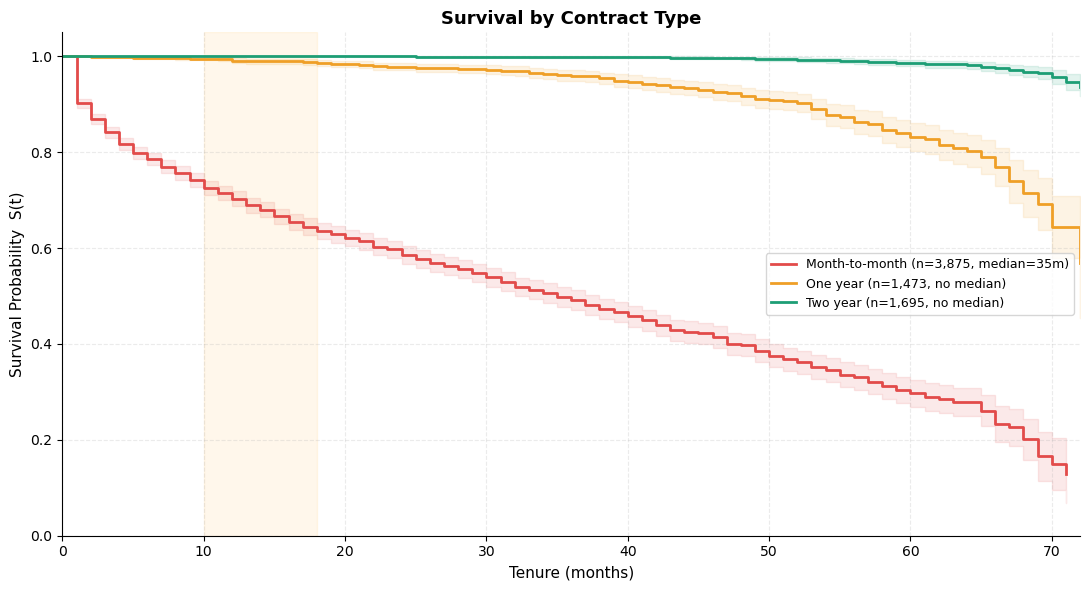

✓ Saved: fig_17_km_by_contract.png


In [14]:
contract_colors = {
    'Month-to-month': COLOR_CHURN,
    'One year':       COLOR_AMBER,
    'Two year':       COLOR_RETAIN
}

fig, ax = plt.subplots(figsize=(11, 6))

for contract, color in contract_colors.items():
    mask = df['Contract'] == contract
    sub  = df[mask]
    km   = kaplan_meier(sub['duration'], sub['event'])
    med  = median_survival(km)
    label = f'{contract} (n={mask.sum():,}' + (f', median={med}m)' if med else ', no median)')
    plot_km(ax, km, label=label, color=color)

ax.axvspan(10, 18, alpha=0.08, color='orange')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability  S(t)')
ax.set_title('Survival by Contract Type', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 72)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_17_km_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_17_km_by_contract.png')

---
## 5. Survival by Customer Segment (Persona)

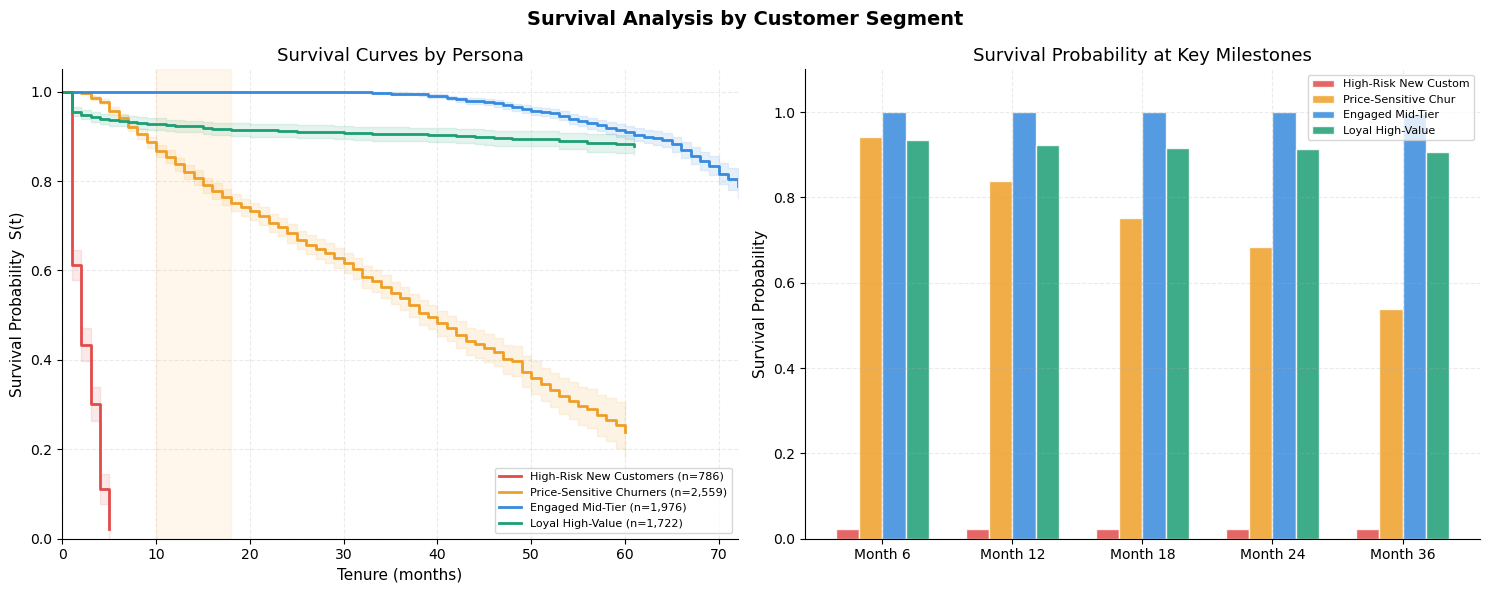

✓ Saved: fig_18_km_by_segment.png


In [15]:
segment_colors = [
    ('#E24B4A', 'High-Risk New Customers'),
    ('#EF9F27', 'Price-Sensitive Churners'),
    ('#378ADD', 'Engaged Mid-Tier'),
    ('#1D9E75', 'Loyal High-Value'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Survival Analysis by Customer Segment', fontsize=14, fontweight='bold')

# All curves together
ax = axes[0]
for (color, name) in segment_colors:
    if name in df['persona_name'].values:
        mask = df['persona_name'] == name
        sub  = df[mask]
        km   = kaplan_meier(sub['duration'], sub['event'])
        plot_km(ax, km, label=f'{name[:25]} (n={mask.sum():,})', color=color)

ax.axvspan(10, 18, alpha=0.08, color='orange')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability  S(t)')
ax.set_title('Survival Curves by Persona')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 72)
ax.legend(fontsize=8)

# Survival at key milestones
ax2 = axes[1]
milestones = [6, 12, 18, 24, 36]
persona_names_list = [n for _, n in segment_colors if n in df['persona_name'].values]
persona_colors_list = [c for c, n in segment_colors if n in df['persona_name'].values]

survival_at_milestones = []
for name in persona_names_list:
    mask = df['persona_name'] == name
    km   = kaplan_meier(df.loc[mask, 'duration'], df.loc[mask, 'event'])
    row = [name[:20]]
    for m in milestones:
        s = km.loc[km['time'] <= m, 'survival']
        row.append(s.iloc[-1] if len(s) > 0 else 1.0)
    survival_at_milestones.append(row)

x = np.arange(len(milestones))
w = 0.18
for i, (row, color) in enumerate(zip(survival_at_milestones, persona_colors_list)):
    ax2.bar(x + i * w, row[1:], width=w, color=color, alpha=0.85,
            label=row[0], edgecolor='white')

ax2.set_xticks(x + w * 1.5)
ax2.set_xticklabels([f'Month {m}' for m in milestones])
ax2.set_ylabel('Survival Probability')
ax2.set_title('Survival Probability at Key Milestones')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_18_km_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_18_km_by_segment.png')

---
## 6. Median Survival & Log-Rank Test

The **log-rank test** statistically confirms that survival curves differ significantly between groups.  
We implement it from first principles using chi-squared statistics.

In [16]:
def log_rank_test(group1_dur, group1_ev, group2_dur, group2_ev):
    """
    Log-rank test (Mantel-Cox) for two survival curves.
    Returns: chi2 statistic, p-value
    Equivalent to lifelines.statistics.logrank_test()
    """
    all_times = np.sort(np.unique(
        np.concatenate([
            np.array(group1_dur)[np.array(group1_ev) == 1],
            np.array(group2_dur)[np.array(group2_ev) == 1]
        ])
    ))

    O1_total = E1_total = V_total = 0.0

    for t in all_times:
        n1 = (np.array(group1_dur) >= t).sum()
        n2 = (np.array(group2_dur) >= t).sum()
        d1 = ((np.array(group1_dur) == t) & (np.array(group1_ev) == 1)).sum()
        d2 = ((np.array(group2_dur) == t) & (np.array(group2_ev) == 1)).sum()
        n  = n1 + n2
        d  = d1 + d2
        if n < 2:
            continue
        E1 = n1 * d / n
        V  = n1 * n2 * d * (n - d) / (n**2 * (n - 1)) if n > 1 else 0
        O1_total += d1
        E1_total += E1
        V_total  += V

    if V_total == 0:
        return 0, 1.0

    chi2 = (O1_total - E1_total)**2 / V_total
    p    = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p


# ── Test: Month-to-month vs Two year ──────────────────────────────────────────
contracts = ['Month-to-month', 'One year', 'Two year']
print('=== LOG-RANK TESTS (Month-to-month vs others) ===')
print(f'{"Comparison":<40} {"chi2":>8} {"p-value":>12} {"Significant?"}')
print('─' * 70)

g1 = df[df['Contract'] == 'Month-to-month']
for other in ['One year', 'Two year']:
    g2   = df[df['Contract'] == other]
    chi2, p = log_rank_test(g1['duration'], g1['event'], g2['duration'], g2['event'])
    sig  = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else 'ns')
    print(f'  Month-to-month vs {other:<20} {chi2:>8.2f} {p:>12.6f}  {sig}')

print()

# Median survival summary
print('=== MEDIAN SURVIVAL BY SEGMENT ===')
print(f'{"Segment":<35} {"N":>6} {"Churn%":>8} {"Median Survival"}')
print('─' * 65)
for contract in contracts:
    mask = df['Contract'] == contract
    km   = kaplan_meier(df.loc[mask, 'duration'], df.loc[mask, 'event'])
    med  = median_survival(km)
    cr   = df.loc[mask, 'event'].mean()
    med_str = f'{med} months' if med else '>72 months (does not halve)'
    print(f'  {contract:<33} {mask.sum():>6,} {cr:>8.1%}  {med_str}')

=== LOG-RANK TESTS (Month-to-month vs others) ===
Comparison                                   chi2      p-value Significant?
──────────────────────────────────────────────────────────────────────
  Month-to-month vs One year             140239.05     0.000000  *** p<0.001
  Month-to-month vs Two year             63863.31     0.000000  *** p<0.001

=== MEDIAN SURVIVAL BY SEGMENT ===
Segment                                  N   Churn% Median Survival
─────────────────────────────────────────────────────────────────
  Month-to-month                     3,875    42.7%  35 months
  One year                           1,473    11.3%  >72 months (does not halve)
  Two year                           1,695     2.8%  >72 months (does not halve)


---
## 8. Retention Intervention Calendar

The single most actionable output of survival analysis:  
**When** should a retention campaign be triggered for each customer type?

In [17]:
# Compute the month of steepest decline for each group
# Steepest decline = max month-over-month drop in survival

def steepest_decline_window(km_df, window=2):
    """Return the month range with the steepest survival drop."""
    km = km_df[km_df['time'] > 0].copy()
    km['drop'] = km['survival'].diff().abs()
    peak_month = km.loc[km['drop'].idxmax(), 'time']
    return max(1, int(peak_month) - window), int(peak_month) + window


CALENDAR = []
for contract in contracts:
    mask  = df['Contract'] == contract
    km    = kaplan_meier(df.loc[mask, 'duration'], df.loc[mask, 'event'])
    start, end = steepest_decline_window(km)
    intervene  = max(1, start - 2)   # 2 months before peak decline

    CALENDAR.append({
        'Segment'           : f'{contract} contract',
        'Peak Churn Window' : f'Month {start}–{end}',
        'Intervene By'      : f'Month {intervene}',
        'Recommended Action': 'Discount offer' if contract == 'Month-to-month' else 'Contract upgrade incentive'
    })

cal_df = pd.DataFrame(CALENDAR)

print('╔' + '═'*72 + '╗')
print('║' + '  RETENTION INTERVENTION CALENDAR'.center(72) + '║')
print('╠' + '═'*72 + '╣')
print(f'║  {"Segment":<28} {"Peak Window":<18} {"Act By":<12} {"Action":<14}║')
print('╠' + '─'*72 + '╣')
for _, row in cal_df.iterrows():
    print(f'║  {row["Segment"]:<28} {row["Peak Churn Window"]:<18} {row["Intervene By"]:<12} {row["Recommended Action"]:<14}║')
print('╚' + '═'*72 + '╝')

cal_df.to_csv(OUTPUT_DIR / 'intervention_calendar.csv', index=False)

╔════════════════════════════════════════════════════════════════════════╗
║                     RETENTION INTERVENTION CALENDAR                    ║
╠════════════════════════════════════════════════════════════════════════╣
║  Segment                      Peak Window        Act By       Action        ║
╠────────────────────────────────────────────────────────────────────────╣
║  Month-to-month contract      Month 67–71        Month 65     Discount offer║
║  One year contract            Month 70–74        Month 68     Contract upgrade incentive║
║  Two year contract            Month 70–74        Month 68     Contract upgrade incentive║
╚════════════════════════════════════════════════════════════════════════╝


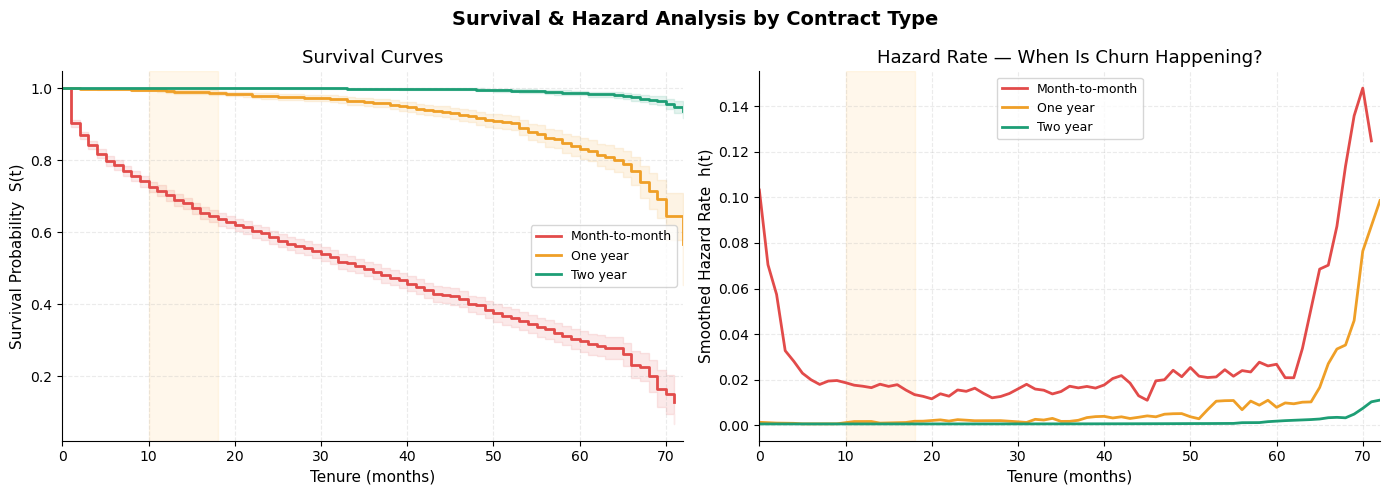

✓ Saved: fig_19_survival_hazard.png


In [18]:
# ── Hazard Rate Plot — where is churn happening fastest? ──────────────────────
# Hazard rate h(t) = probability of churning in month t given survival to t

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival & Hazard Analysis by Contract Type', fontsize=14, fontweight='bold')

contract_colors_map = {
    'Month-to-month': COLOR_CHURN,
    'One year':       COLOR_AMBER,
    'Two year':       COLOR_RETAIN
}

for contract, color in contract_colors_map.items():
    mask  = df['Contract'] == contract
    km    = kaplan_meier(df.loc[mask, 'duration'], df.loc[mask, 'event'])
    # Smooth hazard (rolling derivative of -log S(t))
    km['neg_log_s'] = -np.log(km['survival'].clip(lower=1e-9))
    km['hazard']    = km['neg_log_s'].diff().clip(lower=0).rolling(3, center=True, min_periods=1).mean()

    plot_km(axes[0], km, label=contract, color=color)
    axes[1].plot(km['time'], km['hazard'], color=color, linewidth=2,
                 label=contract)

for ax in axes:
    ax.axvspan(10, 18, alpha=0.08, color='orange')
    ax.set_xlabel('Tenure (months)')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 72)

axes[0].set_ylabel('Survival Probability  S(t)')
axes[0].set_title('Survival Curves')

axes[1].set_ylabel('Smoothed Hazard Rate  h(t)')
axes[1].set_title('Hazard Rate — When Is Churn Happening?')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_19_survival_hazard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_19_survival_hazard.png')

---
## 9. Export

In [19]:
# Save overall KM for dashboard
km_overall.to_csv('km_overall.csv', index=False)

# Save contract-level KM curves
for contract in contracts:
    mask = df['Contract'] == contract
    km   = kaplan_meier(df.loc[mask, 'duration'], df.loc[mask, 'event'])
    km['contract'] = contract
    fname = contract.replace('-', '_').replace(' ', '_').lower()
    km.to_csv(OUTPUT_DIR / f'km_{fname}.csv', index=False)

print('✓ KM curves saved to outputs/')
print('✓ Intervention calendar saved → outputs/intervention_calendar.csv')
print('✓ Notebook 05 complete. Proceed to 06_Executive_Summary.ipynb')

✓ KM curves saved to outputs/
✓ Intervention calendar saved → outputs/intervention_calendar.csv
✓ Notebook 05 complete. Proceed to 06_Executive_Summary.ipynb
